In [1]:
import os
import io
from io import BytesIO
import gzip
import json
import pickle
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from dotenv import load_dotenv
from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model
from google.cloud import storage

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde
/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Comparing base models of ProGen2 and ESM2 on DMS Spearman task

In [3]:
base_sp_df = pd.read_csv("Data/base_spearman.csv.gz", index_col=0)

In [4]:
base_sp_df.shape

(522, 3)

In [5]:
base_sp_df.head()

,domain_id,ESM2_spearman,PG2_spearman
0,Q9Y6N9_PF00595_207,0.378841,0.497253
1,P20936_PF00018_281,0.422455,0.313600
2,Q86VP1_PF18112_729,0.299746,0.197311
3,P22681_PF00627_854,0.235321,0.352885
4,Q9P0J7_PF05605_76,0.303563,0.437686


In [6]:
base_sp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 522 entries, 0 to 521
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   domain_id      522 non-null    object 
 1   ESM2_spearman  522 non-null    float64
 2   PG2_spearman   522 non-null    float64
dtypes: float64(2), object(1)
memory usage: 16.3+ KB


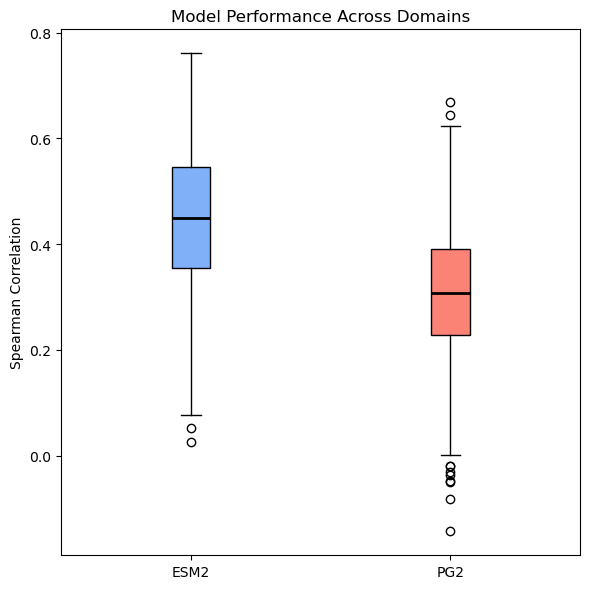

In [7]:
plot_df = base_sp_df.melt(
    id_vars="domain_id",
    value_vars=["ESM2_spearman", "PG2_spearman"],
    var_name="Model",
    value_name="Spearman"
)

fig, ax = plt.subplots(figsize=(6, 6))

bp = ax.boxplot(
    [
        plot_df.loc[plot_df["Model"] == "ESM2_spearman", "Spearman"],
        plot_df.loc[plot_df["Model"] == "PG2_spearman", "Spearman"],
    ],
    labels=["ESM2", "PG2"],
    patch_artist=True,
)

# Set box colors
colors = ["#80b0f8", "#fa8376"]  # blue, salmon

for box, color in zip(bp["boxes"], colors):
    box.set_facecolor(color)

# Make median lines black
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

ax.set_ylabel("Spearman Correlation")
ax.set_title("Model Performance Across Domains")

plt.tight_layout()
plt.show()

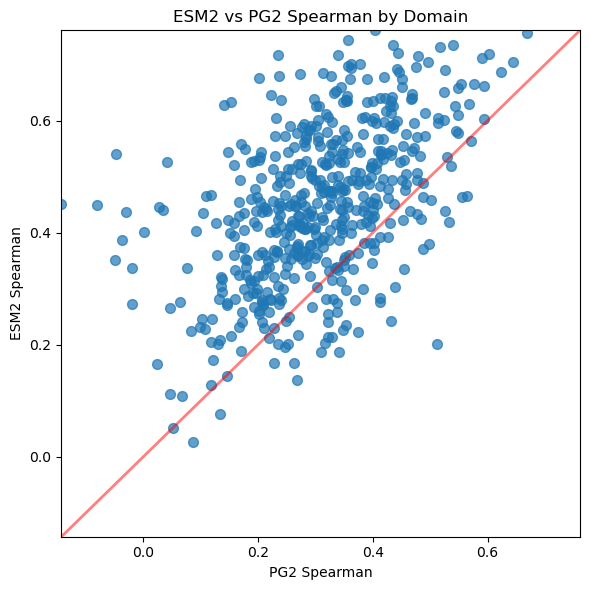

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    base_sp_df["PG2_spearman"],
    base_sp_df["ESM2_spearman"],
    alpha=0.7,
    s=50
)

# y = x reference line
lims = [
    min(base_sp_df["PG2_spearman"].min(), base_sp_df["ESM2_spearman"].min()),
    max(base_sp_df["PG2_spearman"].max(), base_sp_df["ESM2_spearman"].max())
]
ax.plot(lims, lims, alpha=0.5, color='red', linewidth=2)

ax.set_xlabel("PG2 Spearman")
ax.set_ylabel("ESM2 Spearman")
ax.set_title("ESM2 vs PG2 Spearman by Domain")

ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.show()

In [9]:
stat, p_value = wilcoxon(base_sp_df["ESM2_spearman"], base_sp_df["PG2_spearman"], alternative="greater")

print("Wilcoxon statistic:", stat)
print("p-value:", p_value)

Wilcoxon statistic: 128793.0
p-value: 2.511502536130298e-69


# Comparing fine-tuned ESM2 models on DMS Spearman task

In [10]:
df_pfam_all_rho = pd.read_csv("Data/ESM2_PFAM_ALL_sp.csv.gz", index_col=0)

In [11]:
df_pfam_all_rho.columns

Index(['domain_id', 'pfam_id', 'base_rho', 'ft_ALL_rho', 'ft_PF00046_rho_n37',
       'ft_PF00096_rho_n36', 'ft_PF00018_rho_n36', 'ft_PF00595_rho_n31',
       'ft_PF00397_rho_n26', 'ft_PF00505_rho_n17',
       ...
       'ft_PF00173_rho_n1', 'ft_PF05129_rho_n1', 'ft_PF18346_rho_n1',
       'ft_PF01023_rho_n1', 'ft_PF01281_rho_n1', 'ft_PF18387_rho_n1',
       'ft_PF07653_rho_n1', 'ft_PF13341_rho_n1', 'ft_PF09011_rho_n1',
       'ft_PF05741_rho_n1'],
      dtype='object', length=130)

In [12]:
df_pfam_all_rho.shape

(522, 130)

In [13]:
df_pfam_all_rho.head()

,domain_id,pfam_id,base_rho,ft_ALL_rho,ft_PF00046_rho_n37,ft_PF00096_rho_n36,ft_PF00018_rho_n36,ft_PF00595_rho_n31,ft_PF00397_rho_n26,ft_PF00505_rho_n17,...,ft_PF00173_rho_n1,ft_PF05129_rho_n1,ft_PF18346_rho_n1,ft_PF01023_rho_n1,ft_PF01281_rho_n1,ft_PF18387_rho_n1,ft_PF07653_rho_n1,ft_PF13341_rho_n1,ft_PF09011_rho_n1,ft_PF05741_rho_n1
0,Q9Y6N9_PF00595_207,PF00595,0.378841,0.626113,0.407044,0.633606,0.378542,0.661614,0.379123,0.279686,...,0.387309,0.388459,0.383830,0.363722,0.375922,0.375464,0.371727,0.381273,0.378425,0.375639
1,P20936_PF00018_281,PF00018,0.422455,0.666934,0.340823,0.557630,0.424785,0.629427,0.423019,0.314266,...,0.420739,0.428673,0.424374,0.395134,0.422891,0.407285,0.444938,0.423156,0.420516,0.419652
2,Q86VP1_PF18112_729,PF18112,0.299746,0.531721,0.341736,0.415595,0.299951,0.413504,0.300894,0.153747,...,0.287383,0.313183,0.304743,0.312386,0.299976,0.322121,0.292600,0.297300,0.298335,0.302760
3,P22681_PF00627_854,PF00627,0.235321,0.457588,0.255850,0.410761,0.233061,0.423900,0.235649,0.197639,...,0.239267,0.247705,0.238320,0.221485,0.234028,0.229976,0.236586,0.235735,0.233723,0.234571
4,Q9P0J7_PF05605_76,PF05605,0.303563,0.520061,0.370226,0.368095,0.305097,0.503477,0.304922,0.216828,...,0.298062,0.326234,0.309549,0.328282,0.305513,0.305743,0.303561,0.305175,0.303796,0.308627


In [14]:
df_pfam_all_rho.sort_values(by="domain_id", inplace=True)

In [15]:
df_dom_rho = pd.read_csv("Data/ESM2_DOMs_sp.csv.gz", index_col=0)

In [16]:
df_dom_rho.sort_values(by="domain_id", inplace=True)

In [17]:
df_dom_rho.head()

,domain_id,ft_A0PJY2_PF00096_289_rho,ft_A1X283_PF00018_155_rho,ft_A1X283_PF00018_222_rho,ft_A6NK59_PF07525_532_rho,ft_O00308_PF00397_440_rho,ft_O00330_PF02817_181_rho,ft_O14529_PF02376_1036_rho,ft_O14529_PF02376_895_rho,ft_O14640_PF00595_246_rho,...,ft_Q9Y3R0_PF00595_666_rho,ft_Q9Y462_PF00096_506_rho,ft_Q9Y4I5_PF03638_368_rho,ft_Q9Y4J8_PF00569_235_rho,ft_Q9Y5K6_PF00018_271_rho,ft_Q9Y5K6_PF14604_1_rho,ft_Q9Y5K6_PF14604_109_rho,ft_Q9Y618_PF00249_613_rho,ft_Q9Y6N9_PF00595_207_rho,ft_Q9Y6V0_PF05715_1058_rho
0,A0PJY2_PF00096_289,0.362050,0.269420,0.285632,0.225702,0.277239,0.297127,0.241277,0.289096,0.293694,...,0.243406,0.328332,0.306275,0.232825,0.274359,0.266718,0.282811,-0.140971,0.258847,0.246777
1,A1X283_PF00018_155,0.514951,0.692425,0.568788,0.480220,0.524288,0.496365,0.535574,0.610523,0.476711,...,0.557488,0.508715,-0.035624,0.383882,0.466486,0.527188,0.499763,0.054553,0.574735,0.587501
2,A1X283_PF00018_222,0.392745,0.483955,0.650087,0.419319,0.408866,0.374585,0.434402,0.496161,0.347333,...,0.478978,0.389302,-0.043705,0.358940,0.421204,0.460259,0.364159,0.036088,0.452718,0.503769
3,A6NK59_PF07525_532,0.170460,0.168031,0.171159,0.375954,0.166970,0.161401,0.123124,0.212200,0.181829,...,0.188606,0.171104,-0.198185,0.167426,0.162948,0.159161,0.165446,0.179899,0.165907,0.198124
4,O00308_PF00397_440,0.693012,0.684320,0.688064,0.668723,0.696749,0.683162,0.673104,0.676142,0.696271,...,0.695822,0.705443,-0.045238,0.429055,0.689369,0.692864,0.690995,0.047357,0.693064,0.638962


In [18]:
df_dom_rho.shape

(515, 516)

In [19]:
df_dom_rho.columns

Index(['domain_id', 'ft_A0PJY2_PF00096_289_rho', 'ft_A1X283_PF00018_155_rho',
       'ft_A1X283_PF00018_222_rho', 'ft_A6NK59_PF07525_532_rho',
       'ft_O00308_PF00397_440_rho', 'ft_O00330_PF02817_181_rho',
       'ft_O14529_PF02376_1036_rho', 'ft_O14529_PF02376_895_rho',
       'ft_O14640_PF00595_246_rho',
       ...
       'ft_Q9Y3R0_PF00595_666_rho', 'ft_Q9Y462_PF00096_506_rho',
       'ft_Q9Y4I5_PF03638_368_rho', 'ft_Q9Y4J8_PF00569_235_rho',
       'ft_Q9Y5K6_PF00018_271_rho', 'ft_Q9Y5K6_PF14604_1_rho',
       'ft_Q9Y5K6_PF14604_109_rho', 'ft_Q9Y618_PF00249_613_rho',
       'ft_Q9Y6N9_PF00595_207_rho', 'ft_Q9Y6V0_PF05715_1058_rho'],
      dtype='object', length=516)

In [20]:
df_dpa_rho = pd.merge(df_pfam_all_rho, df_dom_rho, on="domain_id")

In [21]:
df_dpa_rho.shape

(515, 645)

In [22]:
df_dpa_rho.head()

,domain_id,pfam_id,base_rho,ft_ALL_rho,ft_PF00046_rho_n37,ft_PF00096_rho_n36,ft_PF00018_rho_n36,ft_PF00595_rho_n31,ft_PF00397_rho_n26,ft_PF00505_rho_n17,...,ft_Q9Y3R0_PF00595_666_rho,ft_Q9Y462_PF00096_506_rho,ft_Q9Y4I5_PF03638_368_rho,ft_Q9Y4J8_PF00569_235_rho,ft_Q9Y5K6_PF00018_271_rho,ft_Q9Y5K6_PF14604_1_rho,ft_Q9Y5K6_PF14604_109_rho,ft_Q9Y618_PF00249_613_rho,ft_Q9Y6N9_PF00595_207_rho,ft_Q9Y6V0_PF05715_1058_rho
0,A0PJY2_PF00096_289,PF00096,0.276918,0.288998,0.277528,0.230109,0.275556,0.249129,0.276962,0.238357,...,0.243406,0.328332,0.306275,0.232825,0.274359,0.266718,0.282811,-0.140971,0.258847,0.246777
1,A1X283_PF00018_155,PF00018,0.525022,0.574864,0.347224,0.544269,0.522733,0.579333,0.525098,0.437390,...,0.557488,0.508715,-0.035624,0.383882,0.466486,0.527188,0.499763,0.054553,0.574735,0.587501
2,A1X283_PF00018_222,PF00018,0.409388,0.473147,0.337814,0.494072,0.412539,0.481758,0.409078,0.372645,...,0.478978,0.389302,-0.043705,0.358940,0.421204,0.460259,0.364159,0.036088,0.452718,0.503769
3,A6NK59_PF07525_532,PF07525,0.165638,0.228389,0.185630,0.149715,0.165387,0.186504,0.165847,0.151408,...,0.188606,0.171104,-0.198185,0.167426,0.162948,0.159161,0.165446,0.179899,0.165907,0.198124
4,O00308_PF00397_440,PF00397,0.692651,0.656928,0.569817,0.670728,0.693696,0.666999,0.692452,0.658630,...,0.695822,0.705443,-0.045238,0.429055,0.689369,0.692864,0.690995,0.047357,0.693064,0.638962


# Compare all fine-tuned ESM2 models

In [26]:
df = df_dpa_rho

ft_cols = [c for c in df.columns if c.startswith("ft_") and c.endswith("_rho")]

results = []

for col in ft_cols:
    diff = df[col] - df["base_rho"]

    results.append({
        "model": col.split("ft_")[1].split("_rho")[0],
        "n_better_than_base": (diff > 0).sum(),
        "sum_delta_rho": diff.sum(),
        "mean_delta_rho": diff.mean(),
        "median_delta_rho": diff.median(),
    })

model_summary_df = pd.DataFrame(results)

# sort by number improved, then total improvement
model_summary_df = model_summary_df.sort_values(
    ["n_better_than_base", "sum_delta_rho"],
    ascending=False
)

model_summary_df.head(10)

,model,n_better_than_base,sum_delta_rho,mean_delta_rho,median_delta_rho
226,P82979_PF02037_3,487,26.423403,0.051308,0.046596
161,P35251_PF00533_405,482,22.731125,0.044138,0.039459
358,Q8N1P7_PF00030_1358,482,13.581328,0.026372,0.018425
205,P55072_PF02359_26,481,10.937145,0.021237,0.019050
109,P0CI26_PF00643_87,479,14.588112,0.028326,0.021750
64,O94885_PF00536_630,479,11.837155,0.022985,0.020301
310,Q5TCQ9_PF00397_287,479,8.873237,0.017230,0.012433
392,Q96AE4_PF00013_98,478,35.385773,0.068710,0.061305
198,P53673_PF00030_14,475,6.139857,0.011922,0.008420
52,O75478_PF04433_375,473,29.120068,0.056544,0.046866


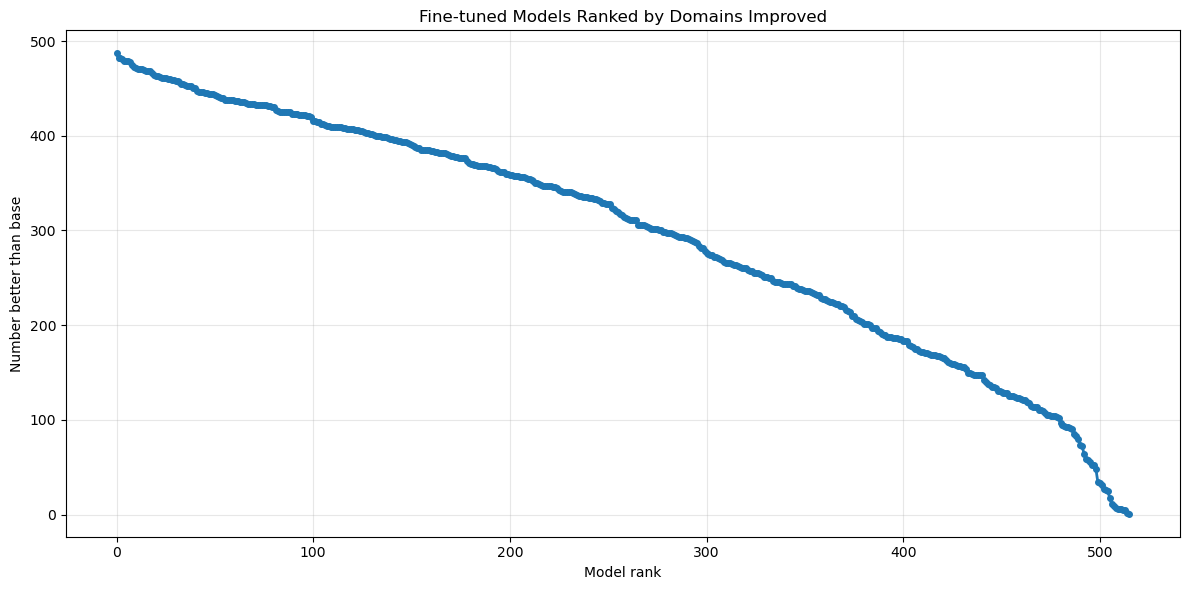

In [27]:
plot_df = model_summary_df.sort_values(
    "n_better_than_base",
    ascending=False
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    plot_df.index,
    plot_df["n_better_than_base"],
    marker="o",
    linewidth=2,
    markersize=4
)

ax.set_xlabel("Model rank")
ax.set_ylabel("Number better than base")
ax.set_title("Fine-tuned Models Ranked by Domains Improved")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
model_summary_df = model_summary_df.sort_values(
    ["sum_delta_rho", "n_better_than_base"],
    ascending=False
)

model_summary_df.head(10)

,model,n_better_than_base,sum_delta_rho,mean_delta_rho,median_delta_rho
125,P13796_PF13499_13,436,47.113169,0.091482,0.085338
265,Q13368_PF00595_132,447,42.458395,0.082443,0.071073
427,Q9BYM8_PF01485_369,445,38.394085,0.074552,0.065199
392,Q96AE4_PF00013_98,478,35.385773,0.068710,0.061305
502,Q9UQR1_PF00096_172,444,34.347368,0.066694,0.055021
343,Q86UP3_PF00046_2562,406,33.816636,0.065663,0.050210
391,Q96AE4_PF00013_184,438,31.607540,0.061374,0.050071
67,O94993_PF00505_338,416,31.309698,0.060796,0.043121
461,Q9NW38_PF11793_305,466,30.861445,0.059925,0.048071
340,Q86UL8_PF00595_774,432,30.258490,0.058754,0.045227


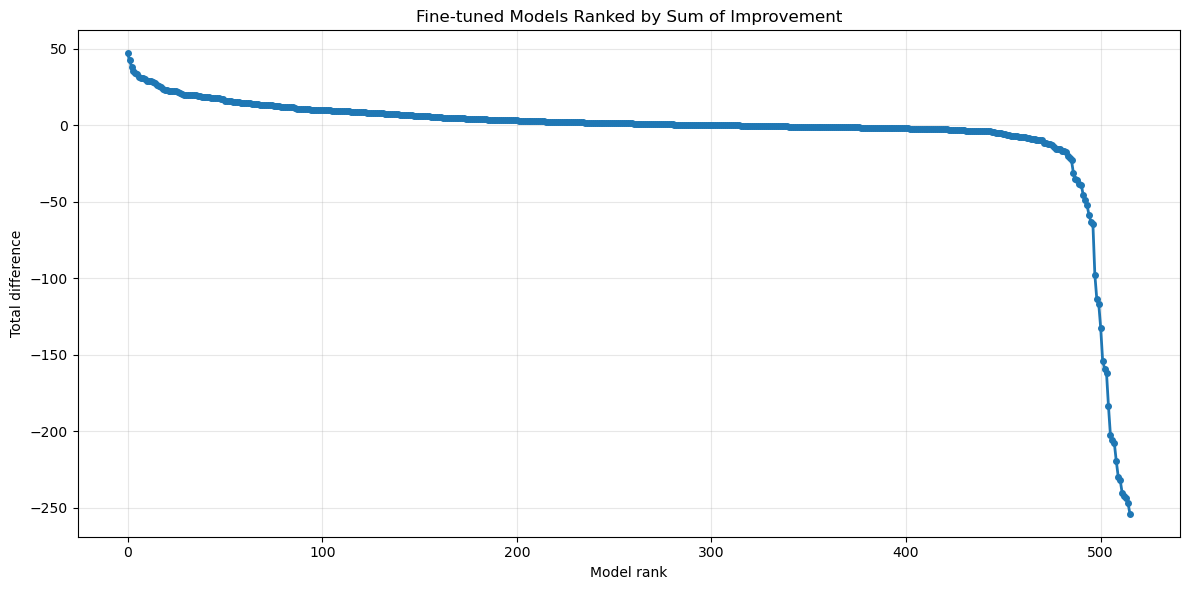

In [29]:
plot_df = model_summary_df.sort_values(
    "sum_delta_rho",
    ascending=False
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    plot_df.index,
    plot_df["sum_delta_rho"],
    marker="o",
    linewidth=2,
    markersize=4
)

ax.set_xlabel("Model rank")
ax.set_ylabel("Total difference")
ax.set_title("Fine-tuned Models Ranked by Sum of Improvement")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### PFAM only

In [35]:
df = df_dpa_rho

ft_cols = [c for c in df.columns if c.startswith("ft_")]

results = []

for col in ft_cols:
    diff = df[col] - df["base_rho"]

    results.append({
        "model": col,
        "n_better_than_base": (diff > 0).sum(),
        "sum_delta_rho": diff.sum(),
        "mean_delta_rho": diff.mean(),
        "median_delta_rho": diff.median(),
    })

model_summary_df = pd.DataFrame(results)

PFAMmodel_summary_df = model_summary_df[
    model_summary_df["model"].str.startswith("ft_PF")
].copy()

# Extract the number after "_n"
PFAMmodel_summary_df["n_train"] = (
    PFAMmodel_summary_df["model"]
    .str.split("_n")
    .str[-1]
    .astype(int)
)

# Keep only models with n > 5
PFAMmodel_summary_df = PFAMmodel_summary_df[
    PFAMmodel_summary_df["n_train"] > 5
]

PFAMmodel_summary_df = PFAMmodel_summary_df.sort_values(
    ["n_better_than_base", "sum_delta_rho"],
    ascending=False
)

PFAMmodel_summary_df["model"] = PFAMmodel_summary_df["model"].str.split("ft_").str[1].str.split("_rho").str[0]

PFAMmodel_summary_df.head(10)

,model,n_better_than_base,sum_delta_rho,mean_delta_rho,median_delta_rho,n_train
19,PF00412,473,34.314902,0.066631,0.051362,8
7,PF00249,470,20.304996,0.039427,0.031006,15
4,PF00595,422,19.014816,0.036922,0.024941,31
23,PF00627,420,9.654256,0.018746,0.013575,7
21,PF02376,413,19.877314,0.038597,0.030358,8
15,PF00013,410,23.762587,0.046141,0.032989,9
20,PF00642,406,14.298031,0.027763,0.018452,8
14,PF00105,403,4.398743,0.008541,0.006607,10
8,PF02037,395,23.923009,0.046452,0.035874,14
27,PF13499,378,2.245701,0.004361,0.002837,6


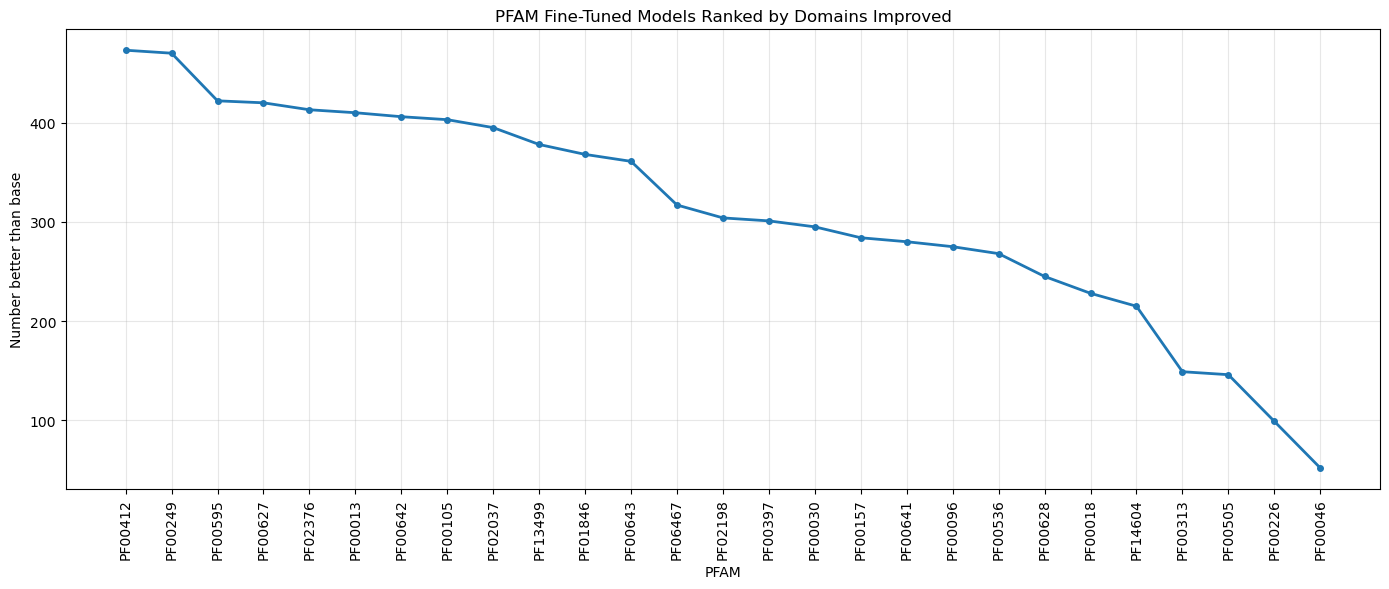

In [37]:
plot_df = (
    PFAMmodel_summary_df
    .sort_values("n_better_than_base", ascending=False)
    .reset_index(drop=True)
    .copy()
)

# ft_PF00412_rho_n8 -> PF00412
plot_df["pfam"] = plot_df["model"]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    plot_df["pfam"],
    plot_df["n_better_than_base"],
    marker="o",
    linewidth=2,
    markersize=4
)

ax.set_xlabel("PFAM")
ax.set_ylabel("Number better than base")
ax.set_title("PFAM Fine-Tuned Models Ranked by Domains Improved")
ax.grid(alpha=0.3)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [38]:
PFAMmodel_summary_df = PFAMmodel_summary_df.sort_values(
    ["sum_delta_rho", "n_better_than_base"],
    ascending=False
)

PFAMmodel_summary_df.head(10)

,model,n_better_than_base,sum_delta_rho,mean_delta_rho,median_delta_rho,n_train
19,PF00412,473,34.314902,0.066631,0.051362,8
8,PF02037,395,23.923009,0.046452,0.035874,14
15,PF00013,410,23.762587,0.046141,0.032989,9
7,PF00249,470,20.304996,0.039427,0.031006,15
21,PF02376,413,19.877314,0.038597,0.030358,8
4,PF00595,422,19.014816,0.036922,0.024941,31
20,PF00642,406,14.298031,0.027763,0.018452,8
16,PF00643,361,9.934180,0.019290,0.010311,9
23,PF00627,420,9.654256,0.018746,0.013575,7
18,PF06467,317,8.811531,0.017110,0.012105,8


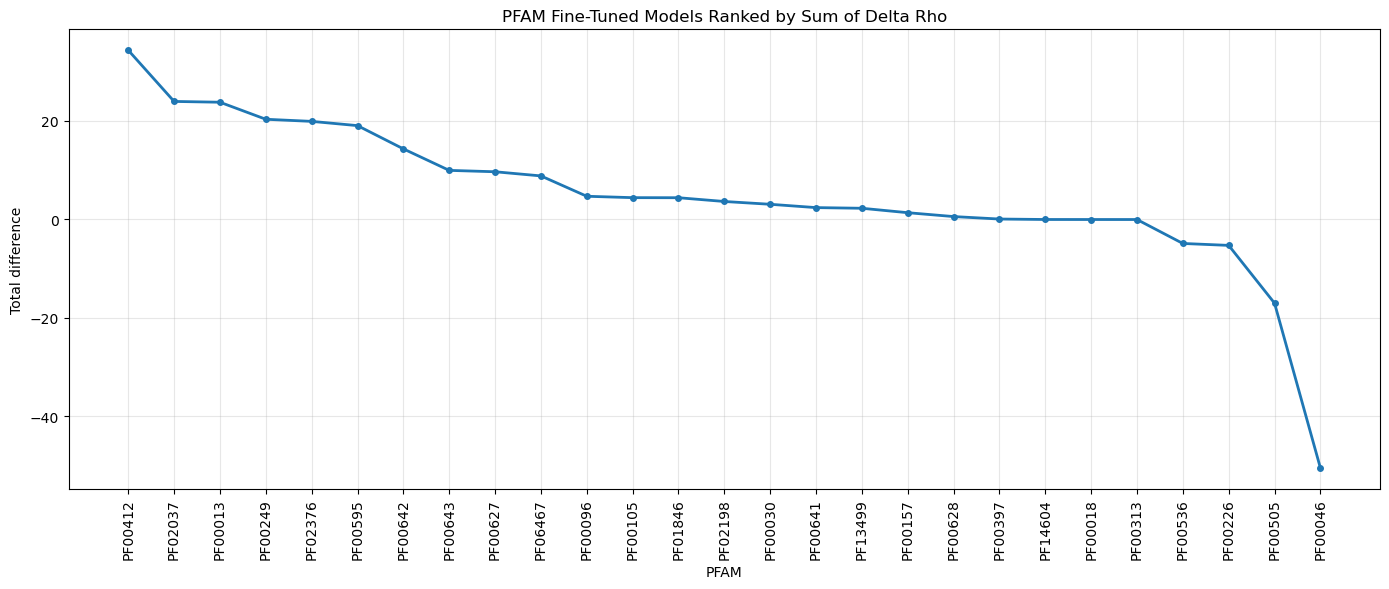

In [39]:
plot_df = (
    PFAMmodel_summary_df
    .sort_values("sum_delta_rho", ascending=False)
    .reset_index(drop=True)
    .copy()
)

# ft_PF00412_rho_n8 -> PF00412
plot_df["pfam"] = plot_df["model"]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    plot_df["pfam"],
    plot_df["sum_delta_rho"],
    marker="o",
    linewidth=2,
    markersize=4
)

ax.set_xlabel("PFAM")
ax.set_ylabel("Total difference")
ax.set_title("PFAM Fine-Tuned Models Ranked by Sum of Delta Rho")
ax.grid(alpha=0.3)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### ft_ALL model

In [40]:
model_summary_df[model_summary_df["model"]=="ft_ALL_rho"]

,model,n_better_than_base,sum_delta_rho,mean_delta_rho,median_delta_rho
0,ft_ALL_rho,363,20.931898,0.040644,0.031484


# Compare base model to ft_ALL model

### Overall proportions

In [26]:
df_all = df_dpa_rho[["domain_id", "pfam_id", "base_rho", "ft_ALL_rho"]]

In [27]:
df_all["delta_rho"] = df_all["ft_ALL_rho"] - df_all["base_rho"]

In [33]:
prop_imp = (df_all["delta_rho"]>0).sum()/len(df_all["delta_rho"])
print(f"The model improved on {prop_imp:.5f} of the 515 domains.")

The model improved on 0.70485 of the 515 domains.


### Statistically significant

In [22]:
valid = df_dpa_rho[["ft_ALL_rho", "base_rho"]].dropna()

stat, p = wilcoxon(
    valid["ft_ALL_rho"],
    valid["base_rho"],
    alternative="greater"
)

median_diff = np.median(
    valid["ft_ALL_rho"] - valid["base_rho"]
)

print(f"Median difference = {median_diff:.4f}")
print(f"Wilcoxon statistic = {stat:.1f}")
print(f"p-value = {p:.3g}")
print(f"n = {len(valid)}")

Median difference = 0.0315
Wilcoxon statistic = 106549.0
p-value = 8.22e-33
n = 515


# Compare PFAM models with n > 4

### On the same PFAM

In [34]:
df_dpa_rho.head()

,domain_id,pfam_id,base_rho,ft_ALL_rho,ft_PF00046_rho_n37,ft_PF00096_rho_n36,ft_PF00018_rho_n36,ft_PF00595_rho_n31,ft_PF00397_rho_n26,ft_PF00505_rho_n17,...,ft_Q9Y3R0_PF00595_666_rho,ft_Q9Y462_PF00096_506_rho,ft_Q9Y4I5_PF03638_368_rho,ft_Q9Y4J8_PF00569_235_rho,ft_Q9Y5K6_PF00018_271_rho,ft_Q9Y5K6_PF14604_1_rho,ft_Q9Y5K6_PF14604_109_rho,ft_Q9Y618_PF00249_613_rho,ft_Q9Y6N9_PF00595_207_rho,ft_Q9Y6V0_PF05715_1058_rho
0,A0PJY2_PF00096_289,PF00096,0.276918,0.288998,0.277528,0.230109,0.275556,0.249129,0.276962,0.238357,...,0.243406,0.328332,0.306275,0.232825,0.274359,0.266718,0.282811,-0.140971,0.258847,0.246777
1,A1X283_PF00018_155,PF00018,0.525022,0.574864,0.347224,0.544269,0.522733,0.579333,0.525098,0.437390,...,0.557488,0.508715,-0.035624,0.383882,0.466486,0.527188,0.499763,0.054553,0.574735,0.587501
2,A1X283_PF00018_222,PF00018,0.409388,0.473147,0.337814,0.494072,0.412539,0.481758,0.409078,0.372645,...,0.478978,0.389302,-0.043705,0.358940,0.421204,0.460259,0.364159,0.036088,0.452718,0.503769
3,A6NK59_PF07525_532,PF07525,0.165638,0.228389,0.185630,0.149715,0.165387,0.186504,0.165847,0.151408,...,0.188606,0.171104,-0.198185,0.167426,0.162948,0.159161,0.165446,0.179899,0.165907,0.198124
4,O00308_PF00397_440,PF00397,0.692651,0.656928,0.569817,0.670728,0.693696,0.666999,0.692452,0.658630,...,0.695822,0.705443,-0.045238,0.429055,0.689369,0.692864,0.690995,0.047357,0.693064,0.638962


### Proportions

In [ ]:
df = df_dpa_rho
base = df["base_rho"]

results = []

for col in df.columns:
    
    # choosing PFAM-trained models with more than 4 domains
    if col.startswith("ft_PF") and "_n" in col:
        
        try:
            pfam = col.split("ft_")[1].split("_rho")[0].split("_n")[0]
            n = int(col.split("_n")[-1])
        except:
            continue
        
        if n > 4:
            
            # matching PFAM
            subset = df[df["pfam_id"] == pfam][["base_rho", col]].dropna()
            
            if len(subset) < 3:
                continue
            
            stat, p = wilcoxon(
                subset[col],
                subset["base_rho"],
                alternative="greater"
            )
            
            results.append({
                "column": col,
                "pfam": pfam,
                "n": n,
                "wilcoxon_stat": stat,
                "p_value": p,
                "median_diff": np.median(subset[col] - subset["base_rho"])
            })

res_df = pd.DataFrame(results)

In [36]:
res_df.head()

,column,pfam,n,wilcoxon_stat,p_value,median_diff
0,ft_PF00046_rho_n37,PF00046,37,74.0,0.999997,-0.091264
1,ft_PF00096_rho_n36,PF00096,36,66.0,0.999998,-0.109370
2,ft_PF00018_rho_n36,PF00018,36,590.0,0.000007,0.001854
3,ft_PF00595_rho_n31,PF00595,31,351.0,0.021727,0.014386
4,ft_PF00397_rho_n26,PF00397,26,179.0,0.470150,-0.000087


In [40]:
prop_imp_med_PFAM = (res_df["median_diff"] > 0).sum()/len(res_df["median_diff"])
print(f"There were {(res_df["median_diff"] > 0).sum()} models with improved median Spearman coefficients out of {len(res_df["median_diff"])}")
print(f"A proportion of {prop_imp_med_PFAM:.5f}")

There were 20 models with improved median Spearman coefficients out of 28
A proportion of 0.71429


### Statistically significant

In [41]:
reject, p_by, _, _ = multipletests(
    res_df["p_value"],
    method="fdr_by"
)

res_df["p_fdr"] = p_by
res_df["significant_fdr_0.05"] = reject

In [42]:
res_df = res_df.sort_values("p_fdr")

In [43]:
print("Significant after FDR:", res_df["significant_fdr_0.05"].sum())
print("Total tests:", len(res_df))
res_df.head(10)

Significant after FDR: 9
Total tests: 28


,column,pfam,n,wilcoxon_stat,p_value,median_diff,p_fdr,significant_fdr_0.05
2,ft_PF00018_rho_n36,PF00018,36,590.0,0.000007,0.001854,0.000803,True
6,ft_PF00249_rho_n15,PF00249,15,117.0,0.000153,0.075473,0.008389,True
5,ft_PF00505_rho_n17,PF00505,17,140.0,0.000671,0.081516,0.024609,True
14,ft_PF00013_rho_n9,PF00013,9,45.0,0.001953,0.159569,0.035795,True
12,ft_PF00641_rho_n10,PF00641,10,54.0,0.001953,0.069002,0.035795,True
15,ft_PF00643_rho_n9,PF00643,9,45.0,0.001953,0.069098,0.035795,True
10,ft_PF00157_rho_n12,PF00157,12,73.0,0.002441,0.026049,0.038351,True
18,ft_PF00412_rho_n8,PF00412,8,36.0,0.003906,0.085268,0.047726,True
19,ft_PF00642_rho_n8,PF00642,8,36.0,0.003906,0.123716,0.047726,True
13,ft_PF00105_rho_n10,PF00105,10,52.0,0.004883,0.046142,0.053692,False


### On entire dataset

In [46]:
df_dpa_rho.head()

,domain_id,pfam_id,base_rho,ft_ALL_rho,ft_PF00046_rho_n37,ft_PF00096_rho_n36,ft_PF00018_rho_n36,ft_PF00595_rho_n31,ft_PF00397_rho_n26,ft_PF00505_rho_n17,...,ft_Q9Y3R0_PF00595_666_rho,ft_Q9Y462_PF00096_506_rho,ft_Q9Y4I5_PF03638_368_rho,ft_Q9Y4J8_PF00569_235_rho,ft_Q9Y5K6_PF00018_271_rho,ft_Q9Y5K6_PF14604_1_rho,ft_Q9Y5K6_PF14604_109_rho,ft_Q9Y618_PF00249_613_rho,ft_Q9Y6N9_PF00595_207_rho,ft_Q9Y6V0_PF05715_1058_rho
0,A0PJY2_PF00096_289,PF00096,0.276918,0.288998,0.277528,0.230109,0.275556,0.249129,0.276962,0.238357,...,0.243406,0.328332,0.306275,0.232825,0.274359,0.266718,0.282811,-0.140971,0.258847,0.246777
1,A1X283_PF00018_155,PF00018,0.525022,0.574864,0.347224,0.544269,0.522733,0.579333,0.525098,0.437390,...,0.557488,0.508715,-0.035624,0.383882,0.466486,0.527188,0.499763,0.054553,0.574735,0.587501
2,A1X283_PF00018_222,PF00018,0.409388,0.473147,0.337814,0.494072,0.412539,0.481758,0.409078,0.372645,...,0.478978,0.389302,-0.043705,0.358940,0.421204,0.460259,0.364159,0.036088,0.452718,0.503769
3,A6NK59_PF07525_532,PF07525,0.165638,0.228389,0.185630,0.149715,0.165387,0.186504,0.165847,0.151408,...,0.188606,0.171104,-0.198185,0.167426,0.162948,0.159161,0.165446,0.179899,0.165907,0.198124
4,O00308_PF00397_440,PF00397,0.692651,0.656928,0.569817,0.670728,0.693696,0.666999,0.692452,0.658630,...,0.695822,0.705443,-0.045238,0.429055,0.689369,0.692864,0.690995,0.047357,0.693064,0.638962


In [ ]:
# now rank the models by the number of spearman improvements
# now rank the models by the sum of the differences

In [44]:
df = df_dpa_rho

base = df["base_rho"]

results = []

for col in df.columns:
    # choosing PFAM-trained models with more than 4 domains
    if col.startswith("ft_PF") and "_n" in col:
        
        try:
            n = int(col.split("_n")[-1])
        except:
            continue
        
        if n > 4:
            
            valid = df[["base_rho", col]].dropna()
            
            if len(valid) < 3:
                continue
            
            stat, p = wilcoxon(
                valid[col],
                valid["base_rho"],
                alternative="greater"
            )
            
            results.append({
                "column": col,
                "n": n,
                "wilcoxon_stat": stat,
                "p_value": p,
                "median_diff": np.median(valid[col] - valid["base_rho"])
            })

res_df = pd.DataFrame(results)

In [45]:
prop_imp_med_all = (res_df["median_diff"] > 0).sum()/len(res_df["median_diff"])
print(f"There were {(res_df["median_diff"] > 0).sum()} models with improved median Spearman coefficients out of {len(res_df["median_diff"])}")
print(f"A proportion of {prop_imp_med_all:.5f}")

There were 21 models with improved median Spearman coefficients out of 28
A proportion of 0.75000


### Benjamini–Yekutieli FDR

In [76]:
reject, pvals_corrected, _, _ = multipletests(
    res_df["p_value"],
    method="fdr_by"
)

res_df["p_fdr"] = pvals_corrected
res_df["significant_fdr_0.05"] = reject

In [77]:
res_df = res_df.sort_values("p_fdr")

In [78]:
print("Significant after FDR:", res_df["significant_fdr_0.05"].sum())
print("Total tests:", len(res_df))
res_df.head(10)

Significant after FDR: 19
Total tests: 28


,column,n,wilcoxon_stat,p_value,median_diff,p_fdr,significant_fdr_0.05
6,ft_PF00249_rho_n15,15,129946.0,3.968757e-79,0.031006,4.364077e-77,True
27,ft_PF07647_rho_n5,5,129354.0,1.062698e-77,0.033215,5.842753e-76,True
18,ft_PF00412_rho_n8,8,129190.0,2.627754e-77,0.051362,9.631664e-76,True
3,ft_PF00595_rho_n31,31,119480.0,7.593943e-56,0.024941,2.087590e-54,True
14,ft_PF00013_rho_n9,9,118616.0,4.139112e-54,0.032989,9.102800e-53,True
22,ft_PF00627_rho_n7,7,118150.0,3.481111e-53,0.013575,6.379762e-52,True
20,ft_PF02376_rho_n8,8,118112.0,4.137794e-53,0.030358,6.499930e-52,True
19,ft_PF00642_rho_n8,8,117585.0,4.487114e-52,0.018452,6.167582e-51,True
13,ft_PF00105_rho_n10,10,115527.0,3.924537e-48,0.006607,4.794947e-47,True
7,ft_PF02037_rho_n14,14,112206.0,4.135353e-42,0.035874,4.547267e-41,True


In [79]:
top = res_df.sort_values("p_fdr").head(15)

top = top[[
    "column",
    "n",
    "median_diff",
    "p_fdr",
    "significant_fdr_0.05"
]].copy()

top["median_diff"] = top["median_diff"].round(3)
top["p_fdr"] = top["p_fdr"].apply(lambda x: f"{x:.2e}")

print(top.to_latex(index=False))

\begin{tabular}{lrrlr}
\toprule
column & n & median_diff & p_fdr & significant_fdr_0.05 \\
\midrule
ft_PF00249_rho_n15 & 15 & 0.031000 & 4.36e-77 & True \\
ft_PF07647_rho_n5 & 5 & 0.033000 & 5.84e-76 & True \\
ft_PF00412_rho_n8 & 8 & 0.051000 & 9.63e-76 & True \\
ft_PF00595_rho_n31 & 31 & 0.025000 & 2.09e-54 & True \\
ft_PF00013_rho_n9 & 9 & 0.033000 & 9.10e-53 & True \\
ft_PF00627_rho_n7 & 7 & 0.014000 & 6.38e-52 & True \\
ft_PF02376_rho_n8 & 8 & 0.030000 & 6.50e-52 & True \\
ft_PF00642_rho_n8 & 8 & 0.018000 & 6.17e-51 & True \\
ft_PF00105_rho_n10 & 10 & 0.007000 & 4.79e-47 & True \\
ft_PF02037_rho_n14 & 14 & 0.036000 & 4.55e-41 & True \\
ft_PF13499_rho_n6 & 6 & 0.003000 & 1.60e-36 & True \\
ft_PF00643_rho_n9 & 9 & 0.010000 & 9.02e-32 & True \\
ft_PF01846_rho_n12 & 12 & 0.007000 & 1.46e-24 & True \\
ft_PF00397_rho_n26 & 26 & 0.000000 & 7.34e-11 & True \\
ft_PF06467_rho_n8 & 8 & 0.012000 & 7.34e-11 & True \\
\bottomrule
\end{tabular}



# Compare domain-trained models

In [80]:
dom_cols = [
    c for c in df.columns
    if c.startswith("ft_")
    and c != "ft_ALL_rho"
    and "PF" not in c.split("_")[1]   
]

In [ ]:
results = []

df = df_dpa_rho

base = df["base_rho"]

for col in dom_cols:
    
    valid = df[["base_rho", col]].dropna()
    
    if len(valid) < 3:
        continue
    
    stat, p = wilcoxon(
        valid[col],
        valid["base_rho"],
        alternative="greater"
    )
    
    results.append({
        "column": col,
        "n": len(valid),
        "median_diff": np.median(valid[col] - valid["base_rho"]),
        "wilcoxon_stat": stat,
        "p_value": p
    })

res_df = pd.DataFrame(results)

In [82]:
res_df.head()

,column,n,median_diff,wilcoxon_stat,p_value
0,ft_A0PJY2_PF00096_289_rho,515,-0.004407,9297.0,1.000000e+00
1,ft_A1X283_PF00018_155_rho,515,0.006869,117925.0,9.667219e-53
2,ft_A1X283_PF00018_222_rho,515,0.022918,114307.0,7.158298e-46
3,ft_A6NK59_PF07525_532_rho,515,-0.012564,30265.0,1.000000e+00
4,ft_O00308_PF00397_440_rho,515,-0.000006,68243.0,2.962855e-01


## Benjamini–Yekutieli FDR

In [83]:
reject, p_fdr, _, _ = multipletests(
    res_df["p_value"],
    method="fdr_by"
)

res_df["p_fdr"] = p_fdr
res_df["significant_fdr_0.05"] = reject

In [84]:
res_df = res_df.sort_values("p_fdr")

In [86]:
print("Significant after FDR:", res_df["significant_fdr_0.05"].sum())
print("Total tests:", len(res_df))
res_df.head(10)

Significant after FDR: 298
Total tests: 515


,column,n,median_diff,wilcoxon_stat,p_value,p_fdr,significant_fdr_0.05
204,ft_P55072_PF02359_26_rho,515,0.019050,129934.0,4.243533e-79,1.126164e-75,True
63,ft_O94885_PF00536_630_rho,515,0.020301,129860.0,6.410477e-79,1.126164e-75,True
160,ft_P35251_PF00533_405_rho,515,0.039459,129747.0,1.202475e-78,1.187061e-75,True
357,ft_Q8N1P7_PF00030_1358_rho,515,0.018425,129726.0,1.351424e-78,1.187061e-75,True
225,ft_P82979_PF02037_3_rho,515,0.046596,129649.0,2.073031e-78,1.456724e-75,True
51,ft_O75478_PF04433_375_rho,515,0.046866,129311.0,1.347712e-77,7.892001e-75,True
129,ft_P14921_PF02198_55_rho,515,0.012782,129034.0,6.203455e-77,3.113702e-74,True
391,ft_Q96AE4_PF00013_98_rho,515,0.061305,128933.0,1.080604e-76,4.745893e-74,True
332,ft_Q7Z6G8_PF00536_812_rho,515,0.028143,128671.0,4.540632e-76,1.772618e-73,True
197,ft_P53673_PF00030_14_rho,515,0.008420,128575.0,7.671921e-76,2.695539e-73,True


In [69]:
table = res_df[[
    "column",
    "n",
    "median_diff",
    "p_value",
    "p_fdr",
    "significant_fdr_0.05"
]].copy()

table["median_diff"] = table["median_diff"].round(4)
table["p_value"] = table["p_value"].apply(lambda x: f"{x:.2e}")
table["p_fdr"] = table["p_fdr"].apply(lambda x: f"{x:.2e}")

print(table.to_latex(index=False))

\begin{tabular}{lrrllr}
\toprule
column & n & median_diff & p_value & p_fdr & significant_fdr_0.05 \\
\midrule
ft_O94885_PF00536_630_rho & 515 & 0.020300 & 6.41e-79 & 1.65e-76 & True \\
ft_P55072_PF02359_26_rho & 515 & 0.019000 & 4.24e-79 & 1.65e-76 & True \\
ft_Q8N1P7_PF00030_1358_rho & 515 & 0.018400 & 1.35e-78 & 1.74e-76 & True \\
ft_P35251_PF00533_405_rho & 515 & 0.039500 & 1.20e-78 & 1.74e-76 & True \\
ft_P82979_PF02037_3_rho & 515 & 0.046600 & 2.07e-78 & 2.14e-76 & True \\
ft_O75478_PF04433_375_rho & 515 & 0.046900 & 1.35e-77 & 1.16e-75 & True \\
ft_P14921_PF02198_55_rho & 515 & 0.012800 & 6.20e-77 & 4.56e-75 & True \\
ft_Q96AE4_PF00013_98_rho & 515 & 0.061300 & 1.08e-76 & 6.96e-75 & True \\
ft_Q7Z6G8_PF00536_812_rho & 515 & 0.028100 & 4.54e-76 & 2.60e-74 & True \\
ft_P53673_PF00030_14_rho & 515 & 0.008400 & 7.67e-76 & 3.95e-74 & True \\
ft_Q5TCQ9_PF00397_287_rho & 515 & 0.012400 & 9.29e-76 & 4.35e-74 & True \\
ft_P0CI26_PF00643_87_rho & 515 & 0.021700 & 3.13e-75 & 1.34e-73 & Tru

### On matching PFAM

In [106]:
df_dpa_rho.head()

,domain_id,pfam_id,base_rho,ft_ALL_rho,ft_PF00046_rho_n37,ft_PF00096_rho_n36,ft_PF00018_rho_n36,ft_PF00595_rho_n31,ft_PF00397_rho_n26,ft_PF00505_rho_n17,...,ft_Q9Y3R0_PF00595_666_rho,ft_Q9Y462_PF00096_506_rho,ft_Q9Y4I5_PF03638_368_rho,ft_Q9Y4J8_PF00569_235_rho,ft_Q9Y5K6_PF00018_271_rho,ft_Q9Y5K6_PF14604_1_rho,ft_Q9Y5K6_PF14604_109_rho,ft_Q9Y618_PF00249_613_rho,ft_Q9Y6N9_PF00595_207_rho,ft_Q9Y6V0_PF05715_1058_rho
0,A0PJY2_PF00096_289,PF00096,0.276918,0.288998,0.277528,0.230109,0.275556,0.249129,0.276962,0.238357,...,0.243406,0.328332,0.306275,0.232825,0.274359,0.266718,0.282811,-0.140971,0.258847,0.246777
1,A1X283_PF00018_155,PF00018,0.525022,0.574864,0.347224,0.544269,0.522733,0.579333,0.525098,0.437390,...,0.557488,0.508715,-0.035624,0.383882,0.466486,0.527188,0.499763,0.054553,0.574735,0.587501
2,A1X283_PF00018_222,PF00018,0.409388,0.473147,0.337814,0.494072,0.412539,0.481758,0.409078,0.372645,...,0.478978,0.389302,-0.043705,0.358940,0.421204,0.460259,0.364159,0.036088,0.452718,0.503769
3,A6NK59_PF07525_532,PF07525,0.165638,0.228389,0.185630,0.149715,0.165387,0.186504,0.165847,0.151408,...,0.188606,0.171104,-0.198185,0.167426,0.162948,0.159161,0.165446,0.179899,0.165907,0.198124
4,O00308_PF00397_440,PF00397,0.692651,0.656928,0.569817,0.670728,0.693696,0.666999,0.692452,0.658630,...,0.695822,0.705443,-0.045238,0.429055,0.689369,0.692864,0.690995,0.047357,0.693064,0.638962


In [97]:
dom_cols = [
    c for c in df.columns
    if c.startswith("ft_")
    and c != "ft_ALL_rho"
    and "PF" not in c.split("_")[1]   
]

In [ ]:
results = []

df = df_dpa_rho

base = df["base_rho"]

for col in dom_cols:
    try:
        pfam = col.split("_")[2]
    except:
        continue
    
    valid = df[df["pfam_id"] == pfam][["base_rho", col]].dropna()
    
    if len(valid) < 3:
        continue
    
    stat, p = wilcoxon(
        valid[col],
        valid["base_rho"],
        alternative="greater"
    )
    
    results.append({
        "column": col,
        "pfam": pfam,
        "n": len(valid),
        "median_diff": np.median(valid[col] - valid["base_rho"]),
        "wilcoxon_stat": stat,
        "p_value": p
    })

res_df = pd.DataFrame(results)

ft_A0PJY2_PF00096_289_rho
PF00096
ft_A1X283_PF00018_155_rho
PF00018
ft_A1X283_PF00018_222_rho
PF00018
ft_A6NK59_PF07525_532_rho
PF07525
ft_O00308_PF00397_440_rho
PF00397
ft_O00330_PF02817_181_rho
PF02817
ft_O14529_PF02376_1036_rho
PF02376
ft_O14529_PF02376_895_rho
PF02376
ft_O14640_PF00595_246_rho
PF00595
ft_O14640_PF00778_4_rho
PF00778
ft_O14776_PF01846_645_rho
PF01846
ft_O14776_PF01846_727_rho
PF01846
ft_O14776_PF01846_793_rho
PF01846
ft_O14776_PF01846_897_rho
PF01846
ft_O14776_PF01846_955_rho
PF01846
ft_O14813_PF00046_92_rho
PF00046
ft_O14901_PF00096_395_rho
PF00096
ft_O14936_PF00595_488_rho
PF00595
ft_O15151_PF00641_299_rho
PF00641
ft_O15259_PF00018_152_rho
PF00018
ft_O15265_PF08313_334_rho
PF08313
ft_O15266_PF00046_119_rho
PF00046
ft_O15344_PF00643_172_rho
PF00643
ft_O15350_PF07647_487_rho
PF07647
ft_O15405_PF00505_256_rho
PF00505
ft_O15541_PF00642_198_rho
PF00642
ft_O43167_PF00096_351_rho
PF00096
ft_O43167_PF00096_435_rho
PF00096
ft_O43186_PF00046_41_rho
PF00046
ft_O43295_PF00018

In [110]:
res_df.head()

,column,pfam,n,median_diff,wilcoxon_stat,p_value
0,ft_A0PJY2_PF00096_289_rho,PF00096,36,-0.013400,189.0,9.890493e-01
1,ft_A1X283_PF00018_155_rho,PF00018,36,0.013773,665.0,2.910383e-11
2,ft_A1X283_PF00018_222_rho,PF00018,36,0.046856,577.0,2.360537e-05
3,ft_O00308_PF00397_440_rho,PF00397,26,0.001191,290.0,1.330361e-03
4,ft_O00330_PF02817_181_rho,PF02817,3,0.019975,5.0,2.500000e-01


In [111]:
reject, p_fdr, _, _ = multipletests(
    res_df["p_value"],
    method="fdr_by"
)

res_df["p_fdr"] = p_fdr
res_df["significant_fdr_0.05"] = reject

In [112]:
res_df = res_df.sort_values("p_fdr")

In [113]:
print("Significant after FDR:", res_df["significant_fdr_0.05"].sum())
print("Total tests:", len(res_df))
res_df.head(10)

Significant after FDR: 151
Total tests: 402


,column,pfam,n,median_diff,wilcoxon_stat,p_value,p_fdr,significant_fdr_0.05
240,ft_Q15911_PF00046_2244_rho,PF00046,37,0.198245,703.0,7.275958e-12,4.807797e-09,True
74,ft_P06239_PF00018_63_rho,PF00018,36,0.017408,666.0,1.455192e-11,4.807797e-09,True
239,ft_Q15911_PF00046_2147_rho,PF00046,37,0.080692,703.0,7.275958e-12,4.807797e-09,True
274,ft_Q86UP3_PF00046_2183_rho,PF00046,37,0.100873,703.0,7.275958e-12,4.807797e-09,True
201,ft_Q08881_PF00018_172_rho,PF00018,36,0.008675,666.0,1.455192e-11,4.807797e-09,True
135,ft_P32243_PF00046_40_rho,PF00046,37,0.134415,703.0,7.275958e-12,4.807797e-09,True
343,ft_Q9H161_PF00046_216_rho,PF00046,37,0.199535,702.0,1.455192e-11,4.807797e-09,True
116,ft_P19878_PF00018_241_rho,PF00018,36,0.017266,666.0,1.455192e-11,4.807797e-09,True
25,ft_O43186_PF00046_41_rho,PF00046,37,0.206368,701.0,2.182787e-11,5.769356e-09,True
127,ft_P23759_PF00046_219_rho,PF00046,37,0.045489,701.0,2.182787e-11,5.769356e-09,True


# ProGen 2 stats

In [4]:
df_pg2 = pd.read_csv("/Users/johnhutchens/Desktop/Practicum/Data/Spearman_Data/PG2_DOMs_sp.csv.gz", index_col=0)

In [5]:
df_pg2.head()

,domain_id,base_spearman,ft_A0PJY2_PF00096_289_rho,ft_A1X283_PF00018_155_rho,ft_A1X283_PF00018_222_rho,ft_A6NK59_PF07525_532_rho,ft_O00308_PF00397_440_rho,ft_O00330_PF02817_181_rho,ft_O14529_PF02376_895_rho,ft_O14640_PF00595_246_rho,...,ft_Q9Y2T7_PF00313_86_rho,ft_Q9Y3R0_PF00595_666_rho,ft_Q9Y462_PF00096_506_rho,ft_Q9Y4I5_PF03638_368_rho,ft_Q9Y4J8_PF00569_235_rho,ft_Q9Y5K6_PF00018_271_rho,ft_Q9Y5K6_PF14604_1_rho,ft_Q9Y5K6_PF14604_109_rho,ft_Q9Y618_PF00249_613_rho,ft_Q9Y6N9_PF00595_207_rho
0,A0PJY2_PF00096_289,0.064622,0.541086,0.013044,0.221442,0.188421,0.021580,0.450150,0.034552,-0.210397,...,0.303468,-0.178128,0.321763,0.392639,0.196824,0.120896,-0.020257,0.076428,0.027036,-0.207350
1,A1X283_PF00018_155,0.407009,-0.119528,0.238502,0.314373,0.137723,0.296803,0.368546,0.052157,0.131827,...,0.173337,-0.005371,0.038536,0.269381,0.058382,0.098733,0.108904,0.072496,0.376930,0.123781
2,A1X283_PF00018_222,0.286978,-0.031525,0.218797,0.267890,0.185102,0.179140,0.297902,0.107961,0.130961,...,0.251882,0.087522,0.025856,0.310946,0.012467,0.110002,0.115491,0.003366,0.223886,0.160876
3,A6NK59_PF07525_532,0.023704,0.094267,0.119482,-0.088181,0.302826,0.011527,-0.057024,0.139878,0.155875,...,0.139091,0.155063,-0.102295,-0.048865,-0.260879,0.103285,0.193246,-0.099004,0.012608,0.144904
4,O00308_PF00397_440,0.442646,0.124206,0.062465,0.438973,0.169334,0.348371,0.625975,-0.011372,-0.052838,...,0.066385,0.065364,0.372595,0.461462,-0.032872,0.043943,0.133788,0.319656,0.460774,-0.039473


In [11]:
df_pg2_same = df_pg2[["domain_id", "base_spearman"]]

In [13]:
df_pg2_same["ft_same_spearman"] = [
    df_pg2.loc[i, f"ft_{dom}_rho"]
    if f"ft_{dom}_rho" in df_pg2.columns else np.nan
    for i, dom in zip(df_pg2_same.index, df_pg2_same["domain_id"])
]

In [15]:
df_pg2_same.head()

,domain_id,base_spearman,ft_same_spearman
0,A0PJY2_PF00096_289,0.064622,0.541086
1,A1X283_PF00018_155,0.407009,0.238502
2,A1X283_PF00018_222,0.286978,0.267890
3,A6NK59_PF07525_532,0.023704,0.302826
4,O00308_PF00397_440,0.442646,0.348371


In [26]:
df_pg2_same.info()

<class 'pandas.core.frame.DataFrame'>
Index: 464 entries, 0 to 463
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   domain_id         464 non-null    object 
 1   base_spearman     464 non-null    float64
 2   ft_same_spearman  463 non-null    float64
dtypes: float64(2), object(1)
memory usage: 30.7+ KB


In [22]:
prop_better = (df_pg2_same["base_spearman"] < df_pg2_same["ft_same_spearman"]).sum()/df_pg2_same["base_spearman"].count()

print(f"Proportion of fine-tuned models performing better on domain it was trained on is {prop_better:.4f}")

Proportion of fine-tuned models performing better on domain it was trained on is 0.3642


In [28]:
valid = df_pg2_same[["ft_same_spearman", "base_spearman"]].dropna()

stat, p = wilcoxon(
    valid["ft_same_spearman"],
    valid["base_spearman"],
    alternative="less"
)

median_diff = np.median(
    valid["ft_same_spearman"] - valid["base_spearman"]
)

print(f"Median difference = {median_diff:.4f}")
print(f"Wilcoxon statistic = {stat:.1f}")
print(f"p-value = {p:.3g}")
print(f"n = {len(valid)}")

Median difference = -0.0502
Wilcoxon statistic = 34870.0
p-value = 3.08e-11
n = 463
